In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [6]:
df = pd.read_csv(r"../data/DT_Placement.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (14, 6)


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,S1,8.6,2,No,73,Yes
1,S2,9.4,2,No,76,Yes
2,S3,9.0,2,No,81,Yes
3,S4,5.2,0,Yes,48,No
4,S5,5.3,0,Yes,44,No


In [7]:
# ------------------------------------------------------------
# Select placed students
# ------------------------------------------------------------
placed_df = df[df["Placed"] == "Yes"].copy()

print("Placed students:", len(placed_df))


Placed students: 8


In [9]:
# ------------------------------------------------------------
# Simple Linear Regression
# X = CGPA
# y = Aptitude
# ------------------------------------------------------------
X = placed_df[["CGPA"]]
y = placed_df["Aptitude"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6, 1)
X_test : (2, 1)
y_train: (6,)
y_test : (2,)


In [10]:
#Standardize CGPA for Gradient Descent


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original CGPA:")
print(X_train.head())

print("\nStandardized CGPA:")
print(X_train_scaled[:5])

Original CGPA:
    CGPA
0    8.6
11   7.5
2    9.0
8    8.7
7    6.2

Standardized CGPA:
[[ 0.77005579]
 [-0.26716221]
 [ 1.14722598]
 [ 0.86434834]
 [-1.49296531]]


In [11]:
#Batch Gradient Descent from scratch

# Convert to NumPy arrays
X_gd = X_train_scaled.flatten()
y_gd = y_train.to_numpy()

m = len(X_gd)

# Initialize parameters
theta_0 = 0.0
theta_1 = 0.0

learning_rate = 0.01
epochs = 1000

loss_history = []

# ------------------------------------------------------------
# Batch Gradient Descent
# ------------------------------------------------------------
for epoch in range(epochs):

    # Prediction
    y_pred = theta_0 + theta_1 * X_gd
    print(" theta_0:", theta_0)
    print(" theta_1:", theta_1)

    # Error
    error = y_pred - y_gd

    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # Gradients
    gradient_theta_0 = (2 / m) * np.sum(error)
    gradient_theta_1 = (2 / m) * np.sum(error * X_gd)

    # Parameter update
    theta_0 -= learning_rate * gradient_theta_0
    theta_1 -= learning_rate * gradient_theta_1

print("Final theta_0:", theta_0)
print("Final theta_1:", theta_1)
print("Final training MSE:", loss_history[-1])

 theta_0: 0.0
 theta_1: 0.0
 theta_0: 1.5433333333333332
 theta_1: 0.05851376322553652
 theta_0: 3.0557999999999996
 theta_1: 0.11585725118656241
 theta_0: 4.5380173333333325
 theta_1: 0.17205386938836775
 theta_0: 5.990590319999999
 theta_1: 0.227126555226137
 theta_0: 7.4141118469333325
 theta_1: 0.2810977873471509
 theta_0: 8.809162943328
 theta_1: 0.3339895948257446
 theta_0: 10.176313017794772
 theta_1: 0.3858235661547664
 theta_0: 11.51612009077221
 theta_1: 0.4366208580572078
 theta_0: 12.829131022290099
 theta_1: 0.48640220412160035
 theta_0: 14.11588173517763
 theta_1: 0.5351879232647052
 theta_0: 15.376897433807411
 theta_1: 0.582997928024948
 theta_0: 16.612692818464595
 theta_1: 0.6298517326899858
 theta_0: 17.823772295428636
 theta_1: 0.675768461261723
 theta_0: 19.010630182853397
 theta_1: 0.7207668552620253
 theta_0: 20.173750912529663
 theta_1: 0.7648652813823217
 theta_0: 21.313609227612403
 theta_1: 0.8080817389802121
 theta_0: 22.43067037639349
 theta_1: 0.8504338674

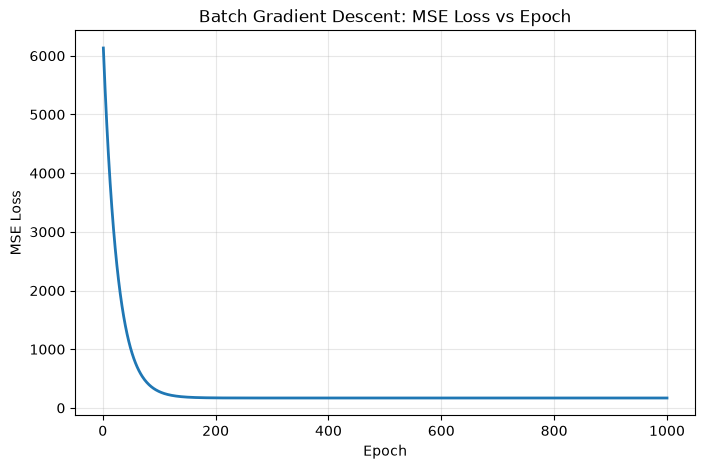

In [12]:
#MSE Curve loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: MSE Loss vs Epoch")
plt.grid(True, alpha=0.3)

plt.show()

In [13]:
X_test_gd = X_test_scaled.flatten()

y_test_pred_gd = theta_0 + theta_1 * X_test_gd

gd_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_gd)
)

gd_mae = mean_absolute_error(
    y_test,
    y_test_pred_gd
)

gd_r2 = r2_score(
    y_test,
    y_test_pred_gd
)

print("Batch GD RMSE:", gd_rmse)
print("Batch GD MAE :", gd_mae)
print("Batch GD R²  :", gd_r2)

Batch GD RMSE: 6.017764857949517
Batch GD MAE : 6.005803769233864
Batch GD R²  : -3.0237215428413533


In [14]:
#Compare with sklearn LinearRegression
sk_model = LinearRegression()

sk_model.fit(
    X_train_scaled,
    y_train
)

y_test_pred_sk = sk_model.predict(
    X_test_scaled
)

sk_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_sk)
)

sk_mae = mean_absolute_error(
    y_test,
    y_test_pred_sk
)

sk_r2 = r2_score(
    y_test,
    y_test_pred_sk
)

print("Sklearn RMSE:", sk_rmse)
print("Sklearn MAE :", sk_mae)
print("Sklearn R²  :", sk_r2)

Sklearn RMSE: 6.017764990371491
Sklearn MAE : 6.005803902198075
Sklearn R²  : -3.0237217199267548


In [15]:
comparison = pd.DataFrame({
    "Model": [
        "Batch Gradient Descent",
        "sklearn LinearRegression"
    ],
    "RMSE": [
        gd_rmse,
        sk_rmse
    ],
    "MAE": [
        gd_mae,
        sk_mae
    ],
    "R²": [
        gd_r2,
        sk_r2
    ]
})

display(comparison)

,Model,RMSE,MAE,R²
0,Batch Gradient Descent,6.017765,6.005804,-3.023722
1,sklearn LinearRegression,6.017765,6.005804,-3.023722


## Using "Mini-Batch Gradient Descent" 

In [31]:
# ------------------------------------------------------------
# Mini-Batch Gradient Descent
# ------------------------------------------------------------

X_mb = X_train_scaled.flatten()
y_mb = y_train.to_numpy()

batch_size = 32
epochs_mb = 1000
learning_rate_mb = 0.01

theta_0_mb = 0.0
theta_1_mb = 0.0

mini_batch_loss = []

rng = np.random.default_rng(42)

n_samples = len(X_mb)

for epoch in range(epochs_mb):

    # Shuffle training data
    indices = rng.permutation(n_samples)

    X_shuffled = X_mb[indices]
    y_shuffled = y_mb[indices]

    # Process mini-batches
    for start in range(0, n_samples, batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        batch_n = len(X_batch)

        # Prediction
        y_batch_pred = (
            theta_0_mb +
            theta_1_mb * X_batch
        )

        # Error
        error = y_batch_pred - y_batch

        # Gradients
        grad_0 = (2 / batch_n) * np.sum(error)

        grad_1 = (
            (2 / batch_n) *
            np.sum(error * X_batch)
        )

        # Update
        theta_0_mb -= learning_rate_mb * grad_0
        theta_1_mb -= learning_rate_mb * grad_1

    # Calculate full training loss after each epoch
    y_epoch_pred = (
        theta_0_mb +
        theta_1_mb * X_mb
    )

    epoch_mse = np.mean(
        (y_epoch_pred - y_mb) ** 2
    )

    mini_batch_loss.append(epoch_mse)

print("Final theta_0:", theta_0_mb)
print("Final theta_1:", theta_1_mb)
print("Final MSE:", mini_batch_loss[-1])

Final theta_0: 14.61840774586733
Final theta_1: 5.323751467693646
Final MSE: 18.545810926198467


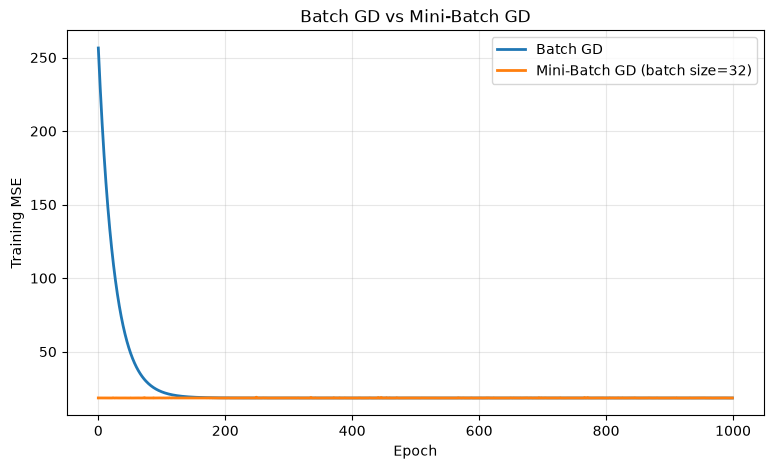

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history,
    label="Batch GD",
    linewidth=2
)

plt.plot(
    mini_batch_loss,
    label="Mini-Batch GD (batch size=32)",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Batch GD vs Mini-Batch GD")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()